## Default setup for a single flap of the FOSWEC

In [1]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

import logging 
logging.getLogger().setLevel(logging.INFO)

In [7]:

def add_flap_thickness(added_thickness):

    flapThicknessBottom = 0.04+added_thickness
    flapThicknessTop    = 0.1+added_thickness
    flapCenterDistanceApart = 1.44
    flapWidth   = 0.76
    flapHeight = 0.58
    flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
    cgHeightAboveHinge = 0.17
    flap1CG     = [0, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin\

    with pygmsh.geo.Geometry() as geom:
        flap1 = geom.add_polygon(
                [[-flapThicknessBottom/2, -flapWidth/2, -flapDraft],
                [flapThicknessBottom/2, -flapWidth/2, -flapDraft],
                [flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
                [-flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
        geom.extrude(flap1,[0,flapWidth,0])
        flap1Mesh = geom.generate_mesh()

    # define the floating body
    flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)

    #axis = cpt.Axis(vector=(0, 1, 0), point=(0, 0, -flapDraft))
    #flap1.add_rotation_dof(name="Pitch_about_hinge", axis=axis)
    #flap1.rotation_center = (0, 0, -flapDraft)

    # try specifying cg at hinge so Capytaine calculates hydrostatics around hinge
    flap1.center_of_mass = flap1CG
    flap1.rotation_center = (0, 0, -flapDraft)
    flap1.add_rotation_dof(name='Pitch')

    flap_mass = 23.1
    flap_inertia_cg = 1.19
    flap_inertia_hinge = flap_inertia_cg + flap_mass*cgHeightAboveHinge**2
    flap1.mass = flap_mass
    rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([flap_inertia_hinge]))),
                                dims=['influenced_dof', 'radiating_dof'],
                                coords={'influenced_dof': list(flap1.dofs),
                                        'radiating_dof': list(flap1.dofs)},
                                name="inertia_matrix")

    # Set FloatingBody inertia matrix
    flap1.inertia_matrix = rigid_inertia_matrix_xr
    flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()
    #flap1.hydrostatic_stiffness = 87 # Nm/rad

    #flap1.show_matplotlib()
    #flap1.show()

    return flap1.hydrostatic_stiffness

INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_18"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.42], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_18 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.io.meshio:Stored 352 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_19"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.42], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rota

Text(0, 0.5, 'Hydrostatic stiffness [N·m/rad]')

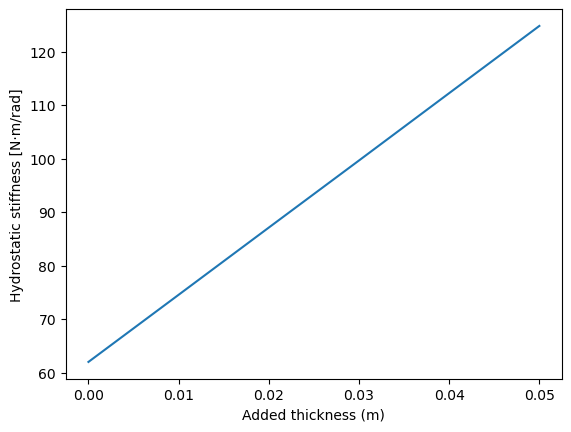

In [8]:
added_thickness_vals = [0, 0.01, 0.02, 0.03, 0.04, 0.05]

hs = []

for added_thickness in added_thickness_vals:
    hs.append(add_flap_thickness(added_thickness))

plt.figure()
plt.plot(added_thickness_vals, np.squeeze(hs))
plt.xlabel('Added thickness (m)')
plt.ylabel('Hydrostatic stiffness [N·m/rad]')